In [158]:
import numpy as np
import pandas as pd

In [159]:
pip install xlrd


Note: you may need to restart the kernel to use updated packages.


***EXPLORATORY DATA ANALYSIS( EDA )***

**LOADING EXCEL FILE**

In [160]:
df = pd.read_excel("Concrete_Data.xls")

**IMPORTANT INFORMATION ABOUT DATA e.g., DIMENSION & SUMMARY STATISTICS,etc**

In [161]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [162]:
df.tail()
df.shape
df.info()
df.describe()
print("Dimension is : ",df.ndim)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [163]:
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

**SELECTING ONE INDEPENDENT AND DEPENDENT VARIABLE**

In [164]:
X = df[['Cement (component 1)(kg in a m^3 mixture)']] #independent variable
Y = df['Concrete compressive strength(MPa, megapascals) '] #dependent variable

**VISUALIZATION**

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Cement (component 1)(kg in a m^3 mixture)', ylabel='Concrete compressive strength(MPa, megapascals) '>

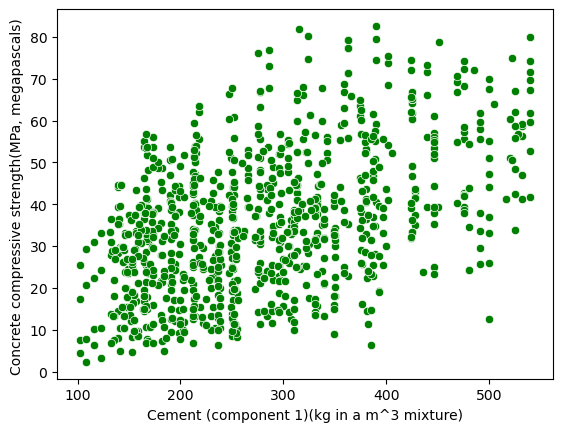

In [166]:
sns.scatterplot(x=df['Cement (component 1)(kg in a m^3 mixture)'], y=Y, color="green")

***DATA CLEANING & TRANSFORMATION***

**OUTLIER DETECTION**

In [167]:
Q1 = df['Concrete compressive strength(MPa, megapascals) '].quantile(0.25)
Q3 = df['Concrete compressive strength(MPa, megapascals) '].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Concrete compressive strength(MPa, megapascals) '] < lower) |
              (df['Concrete compressive strength(MPa, megapascals) '] > upper)]

print(outliers)

     Cement (component 1)(kg in a m^3 mixture)  \
0                                        540.0   
153                                      323.7   
181                                      389.9   
381                                      315.0   

     Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                  0.0       
153                                              282.8       
181                                              189.0       
381                                              137.0       

     Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                           0.0   
153                                         0.0   
181                                         0.0   
381                                         0.0   

     Water  (component 4)(kg in a m^3 mixture)  \
0                                        162.0   
153                                      183.8   
181                             

In [168]:
df_clean = df[~((df < lower) | (df > upper)).any(axis=1)]

In [169]:
df.shape

(1030, 9)

**CHECKING MISSING VALUE OR NOT**

In [170]:
df.isnull().sum() 

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

**BUILDING SIMPLE LINEAR REGRESSION MODEL USING SKLEARN**

$$y = mx + c$$

Where:

- y = Predicted strength
- m = slope
- x = cement amount
- c = intercept

In [171]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

*Splitting dataset into training and testing sets*

In [172]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [173]:
model.fit(X_train,Y_train)

LinearRegression()

In [174]:
pred_Y = model.predict(X_test)
pred_Y

array([34.50557677, 42.03025165, 44.1567902 , 42.03025165, 25.08025937,
       35.31568669, 25.39184011, 33.40024409, 30.34363703, 44.39826528,
       38.16665047, 27.05100755, 50.31829934, 39.00012895, 27.30338795,
       31.54555973, 38.55612639, 33.27483284, 35.05084306, 26.63816307,
       35.03526402, 26.63816307, 36.81984272, 26.7783744 , 30.52513281,
       33.18914814, 31.31187418, 38.16665047, 30.41607955, 40.19192528,
       45.3330075 , 44.39826528, 29.6371277 , 33.01232607, 26.82121675,
       39.68560658, 30.33974227, 34.5211558 , 24.14551715, 36.93279073,
       37.15401306, 22.821299  , 29.25544129, 43.93089416, 31.69901325,
       42.91825676, 43.77510379, 37.69927936, 37.30980343, 24.79204718,
       38.78981195, 32.16872121, 25.9371064 , 27.9545917 , 53.12252601,
       42.91825676, 30.34363703, 33.41504417, 28.61202706, 33.45399177,
       34.50557677, 39.5687638 , 31.69901325, 46.8909112 , 30.29923677,
       26.63816307, 33.42283369, 25.62552566, 31.99813076, 33.36

**FEATURE SCALING (Z-SCORE)**

*$z = \frac{x - \mu}{\sigma}$*

Where:
- x is data point
- ${\mu}$ is mean
- ${\sigma}$ is standard deviation

In [175]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()

X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)

In [176]:
model.fit(X_train,Y_train)
pred_Y = model.predict(X_test)
pred_Y

array([34.50557677, 42.03025165, 44.1567902 , 42.03025165, 25.08025937,
       35.31568669, 25.39184011, 33.40024409, 30.34363703, 44.39826528,
       38.16665047, 27.05100755, 50.31829934, 39.00012895, 27.30338795,
       31.54555973, 38.55612639, 33.27483284, 35.05084306, 26.63816307,
       35.03526402, 26.63816307, 36.81984272, 26.7783744 , 30.52513281,
       33.18914814, 31.31187418, 38.16665047, 30.41607955, 40.19192528,
       45.3330075 , 44.39826528, 29.6371277 , 33.01232607, 26.82121675,
       39.68560658, 30.33974227, 34.5211558 , 24.14551715, 36.93279073,
       37.15401306, 22.821299  , 29.25544129, 43.93089416, 31.69901325,
       42.91825676, 43.77510379, 37.69927936, 37.30980343, 24.79204718,
       38.78981195, 32.16872121, 25.9371064 , 27.9545917 , 53.12252601,
       42.91825676, 30.34363703, 33.41504417, 28.61202706, 33.45399177,
       34.50557677, 39.5687638 , 31.69901325, 46.8909112 , 30.29923677,
       26.63816307, 33.42283369, 25.62552566, 31.99813076, 33.36

**MODEL EVALUATION**

In [177]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score

print("r2 score of model is : ",r2_score(Y_test,pred_Y))
print("MAE score of model is : ",mean_absolute_error(Y_test,pred_Y))
print("MSE of model is : ",mean_squared_error(Y_test,pred_Y))
print("RMSE score of model is : ",root_mean_squared_error(Y_test,pred_Y))

r2 score of model is :  0.25183140674244187
MAE score of model is :  11.555820769998833
MSE of model is :  192.78889718821986
RMSE score of model is :  13.884844154264744


*VISUALIZATION AND PLOTTING THE REGRESSION LINE ( BEST FIT LINE)*

<Axes: xlabel='Cement (component 1)(kg in a m^3 mixture)', ylabel='Concrete compressive strength(MPa, megapascals) '>

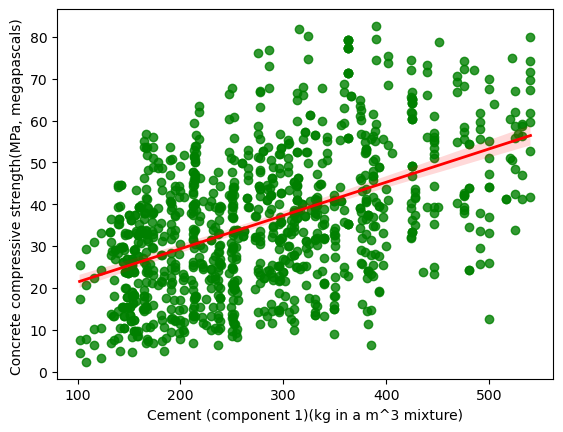

In [178]:
sns.regplot(
    x=df['Cement (component 1)(kg in a m^3 mixture)'],
    y=df['Concrete compressive strength(MPa, megapascals) '],
    scatter_kws={"color": "green"},
    line_kws={"color": "red", "linewidth":2}
)

**MULTIPLE LINEAR REGRESSION**

*Here we have more than one independent features i.e., X1,X2,...Xn and a single dependent variable*

In [179]:
X = df.drop('Concrete compressive strength(MPa, megapascals) ',axis = 1)
Y = df['Concrete compressive strength(MPa, megapascals) ']

In [180]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [181]:
model.fit(X_train,Y_train)

LinearRegression()

*Predicting on the test set*

In [182]:
pred_Y = model.predict(X_test)
pred_Y

array([59.65716303, 52.03714377, 63.51983933, 51.57136586, 17.22016023,
       39.86885347, 26.7014459 , 44.72001905, 29.35815964, 38.19395083,
       27.75960429, 19.81902805, 66.86570362, 52.27861085, 29.97488442,
       44.46971738, 29.22747564, 26.53666548, 31.97285179, 32.03281435,
       36.83075422, 31.78840646, 38.06323109, 25.12704389, 33.10262783,
       33.84686343, 14.24402829, 40.33017694, 41.8734224 , 21.33722165,
       35.72337032, 30.97439331, 43.87999877, 45.52719553, 30.76258029,
       29.59134147, 28.90854895, 38.84992727, 20.35373267, 38.45367912,
       21.16914452, 15.89005619, 31.06597728, 50.70863565, 20.27776785,
       57.64263729, 50.89344091, 60.97165671, 20.00500457, 19.22515249,
       40.48409011, 36.24365771, 30.01371229, 33.43484666, 46.67040038,
       51.47108005, 27.72793697, 15.6989103 , 29.68932338, 18.12663446,
       38.63280045, 20.53807749, 31.57288203, 55.47763222, 22.94017793,
       21.34046484, 32.26815463, 16.70640658, 25.3934816 , 25.54

In [183]:
X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)
model.fit(X_train,Y_train)
pred_Y = model.predict(X_test)
pred_Y

array([59.65716303, 52.03714377, 63.51983933, 51.57136586, 17.22016023,
       39.86885347, 26.7014459 , 44.72001905, 29.35815964, 38.19395083,
       27.75960429, 19.81902805, 66.86570362, 52.27861085, 29.97488442,
       44.46971738, 29.22747564, 26.53666548, 31.97285179, 32.03281435,
       36.83075422, 31.78840646, 38.06323109, 25.12704389, 33.10262783,
       33.84686343, 14.24402829, 40.33017694, 41.8734224 , 21.33722165,
       35.72337032, 30.97439331, 43.87999877, 45.52719553, 30.76258029,
       29.59134147, 28.90854895, 38.84992727, 20.35373267, 38.45367912,
       21.16914452, 15.89005619, 31.06597728, 50.70863565, 20.27776785,
       57.64263729, 50.89344091, 60.97165671, 20.00500457, 19.22515249,
       40.48409011, 36.24365771, 30.01371229, 33.43484666, 46.67040038,
       51.47108005, 27.72793697, 15.6989103 , 29.68932338, 18.12663446,
       38.63280045, 20.53807749, 31.57288203, 55.47763222, 22.94017793,
       21.34046484, 32.26815463, 16.70640658, 25.3934816 , 25.54

**MODEL EVALUATION**

In [184]:
print("r2 score of model is : ",r2_score(Y_test,pred_Y))
print("MAE score of model is : ",mean_absolute_error(Y_test,pred_Y))
print("MSE of model is : ",mean_squared_error(Y_test,pred_Y))
print("RMSE score of model is : ",root_mean_squared_error(Y_test,pred_Y))

r2 score of model is :  0.6275416055429018
MAE score of model is :  7.745392872421347
MSE of model is :  95.97548435337711
RMSE score of model is :  9.796707832398448


<Axes: xlabel='Cement (component 1)(kg in a m^3 mixture)', ylabel='Concrete compressive strength(MPa, megapascals) '>

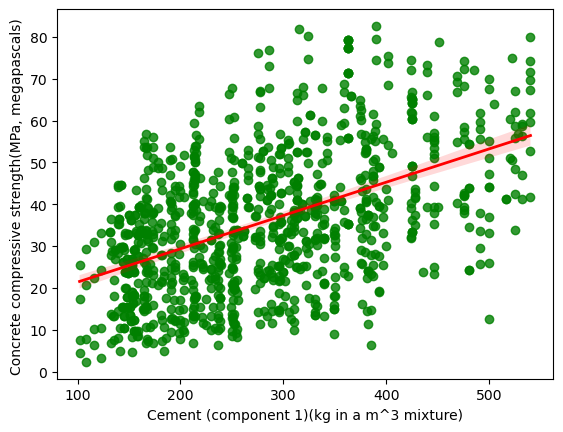

In [185]:
sns.regplot(
    x=df['Cement (component 1)(kg in a m^3 mixture)'],
    y=df['Concrete compressive strength(MPa, megapascals) '],
    scatter_kws={"color": "green"},
    line_kws={"color": "red", "linewidth":2}
)
